In [5]:
import pandas as pd

df = pd.read_csv("https://nmimoto.github.io/datasets/steel.csv")
df["unique_id"] = "Steel"
df.rename(columns={"Month": "ds", "Steel": "y"}, inplace=True)
df["ds"] = pd.to_datetime(df["ds"], format="%Y-%m") + pd.offsets.MonthEnd(0)
df = df[["unique_id", "ds", "y"]]
df

,unique_id,ds,y
0,Steel,1956-01-31,196.9
1,Steel,1956-02-29,192.1
2,Steel,1956-03-31,201.8
3,Steel,1956-04-30,186.9
4,Steel,1956-05-31,218.0
...,...,...,...
450,Steel,1993-07-31,604.0
451,Steel,1993-08-31,613.0
452,Steel,1993-09-30,625.0
453,Steel,1993-10-31,654.0


In [6]:
from statsforecast import StatsForecast
from statsforecast.models import (
    AutoTheta,
    AutoETS,
    AutoARIMA,
    SeasonalNaive
)

models = [
    AutoTheta(),
    AutoETS(),
    AutoARIMA(),
    SeasonalNaive(season_length=12),
]

sf = StatsForecast(
    models=models,
    freq="ME",
    fallback_model=SeasonalNaive(season_length=12),
    n_jobs=-1,
)

forecasts_df = sf.forecast(df=df, h=12, level=[90])
forecasts_df

,unique_id,ds,AutoTheta,AutoTheta-lo-90,AutoTheta-hi-90,AutoETS,AutoETS-lo-90,AutoETS-hi-90,AutoARIMA,AutoARIMA-lo-90,AutoARIMA-hi-90,SeasonalNaive,SeasonalNaive-lo-90,SeasonalNaive-hi-90
0,Steel,1993-12-31,636.578659,568.146545,722.893372,637.281744,550.156175,724.407313,626.206011,552.131825,700.280197,542.0,434.195613,649.804387
1,Steel,1994-01-31,637.203969,551.371704,707.783325,639.024356,545.100327,732.948385,621.839787,539.503501,704.176072,582.0,474.195613,689.804387
2,Steel,1994-02-28,637.829279,530.708435,725.005737,640.766968,540.461962,741.071974,619.566375,532.247549,706.885202,525.0,417.195613,632.804387
3,Steel,1994-03-31,638.454589,545.249268,723.851074,642.509580,536.165756,748.853404,618.555217,527.747738,709.362696,584.0,476.195613,691.804387
4,Steel,1994-04-30,639.079899,536.907898,738.793884,644.252192,532.156261,756.348123,618.305371,524.769276,711.841466,562.0,454.195613,669.804387
5,Steel,1994-05-31,639.705209,538.496399,748.357178,645.994804,528.391265,763.598343,618.514700,522.667802,714.361597,639.0,531.195613,746.804387
6,Steel,1994-06-30,640.330519,522.690369,741.358887,647.737416,524.837768,770.637064,619.000974,521.087630,716.914319,613.0,505.195613,720.804387
7,Steel,1994-07-31,640.955829,520.521179,765.754089,649.480028,521.469394,777.490662,619.654285,519.825618,719.482952,604.0,496.195613,711.804387
8,Steel,1994-08-31,641.581139,517.591248,764.373108,651.222640,518.264675,784.180604,620.408342,518.763213,722.053471,613.0,505.195613,720.804387
9,Steel,1994-09-30,642.206449,522.317810,757.937073,652.965252,515.205866,790.724637,621.223162,517.830196,724.616128,625.0,517.195613,732.804387


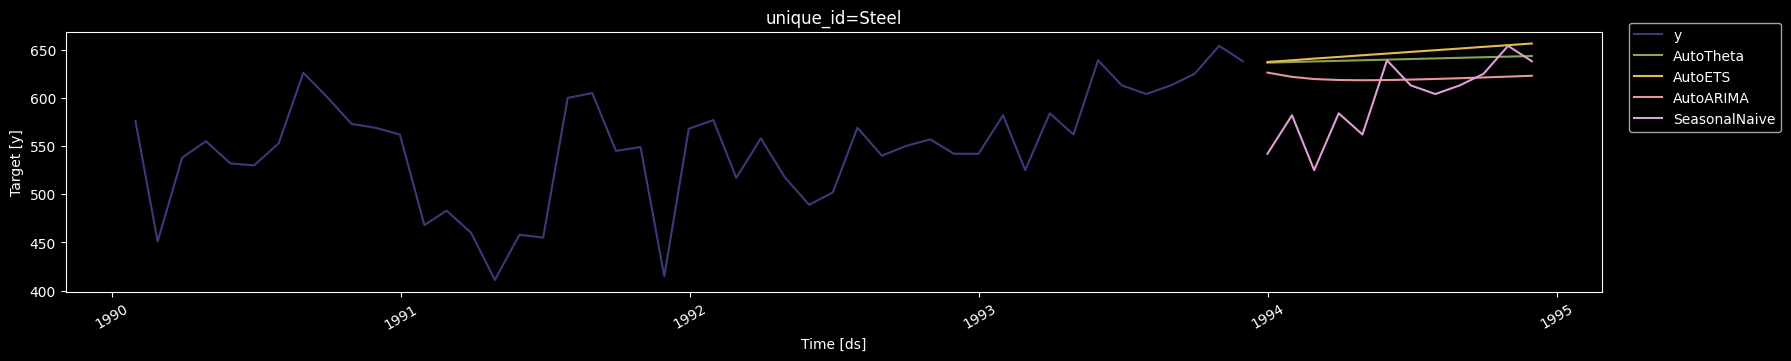

In [11]:
StatsForecast.plot(df.loc[df.ds >= pd.to_datetime("1990-01-01"), :], forecasts_df=forecasts_df)